In [ ]:
import os, random, time, math, tqdm
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

IMG_SIZE = (224, 224)
NUM_CLASSES = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 1
NUM_CLASSES = 4
NUM_EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4

CHECKPOINT_DIR = "checkpoints_4class"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Device =", DEVICE)

Device = cpu


In [ ]:
def per_class_iou(pred, gt, num_classes=4):
    ious = []
    for c in range(num_classes):
        p = (pred==c)
        g = (gt==c)
        inter = (p & g).sum()
        union = (p | g).sum()
        iou = (inter+1e-6)/(union+1e-6)
        ious.append(float(iou))
    return ious

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

p = Path("pseudo_labels/masks")
files = sorted(p.glob("*_class.png"))[:6]
for f in files:
    a = np.array(Image.open(f).convert("L"), dtype=np.uint8)
    print(f.name, np.unique(a))

EARTHQUAKE-TURKEY_000013_class.png [0 3]
EARTHQUAKE-TURKEY_000013_pre_class.png [0 2]
EARTHQUAKE-TURKEY_000042_class.png [0 3]
EARTHQUAKE-TURKEY_000042_pre_class.png [0 1]
EARTHQUAKE-TURKEY_000059_class.png [0]
EARTHQUAKE-TURKEY_000059_pre_class.png [0]


In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
from torchvision import transforms

class PrePostTorchAugDataset(Dataset):
    def __init__(self, csv_path, img_size=(384,384), augment=True, ssl_mode=False, use_post_only=False):
        self.df = pd.read_csv(csv_path)
        self.img_size = img_size
        self.augment = augment
        self.ssl_mode = ssl_mode
        self.use_post_only = use_post_only
        self.resize_img = transforms.Resize(self.img_size)

    def __len__(self):
        return len(self.df)

    def _load_raw(self, pre_path, post_path, mask_path):
        pre = np.array(Image.open(pre_path).convert('RGB'))
        post = np.array(Image.open(post_path).convert('RGB'))
        mask = np.array(Image.open(mask_path))   
        return pre, post, mask

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pre_np, post_np, mask_np = self._load_raw(row['pre'], row['post'], row['mask'])
        pre_img = self.resize_img(Image.fromarray(pre_np))
        post_img = self.resize_img(Image.fromarray(post_np))
        mask_pil = Image.fromarray(mask_np.astype(np.uint8))
        mask_img = mask_pil.resize(self.img_size, resample=Image.NEAREST)
        pre_t = TF.to_tensor(pre_img)
        post_t = TF.to_tensor(post_img)
        mask_t = torch.from_numpy(np.array(mask_img, dtype=np.uint8)).long() 

        if self.use_post_only:
            inp = post_t
        else:
            inp = torch.cat([pre_t, post_t], dim=0)  

        if not self.ssl_mode:
            return inp, mask_t
        return inp, mask_t

In [ ]:
import torch.nn as nn
import torch
import timm
import math

def extract_vit_tokens(vit, x):
    x = vit.patch_embed(x)  

    if x.dim() == 4:
        B, C, Hf, Wf = x.shape
        x = x.flatten(2).transpose(1,2)  

    B, N, D = x.shape
    cls = vit.cls_token.expand(B, -1, -1)
    x = torch.cat([cls, x], dim=1)
    x = x + vit.pos_embed[:, :x.shape[1], :]
    x = vit.pos_drop(x)
    for blk in vit.blocks:
        x = blk(x)
    x = vit.norm(x)
    return x[:,1:]  

import timm, torch.nn as nn, torch
import math, torch.nn.functional as F

class ViTSeg4(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.vit = timm.create_model("vit_tiny_patch16_224", pretrained=True, num_classes=0)
        self.embed_dim = self.vit.embed_dim

        old_patch = self.vit.patch_embed
        ks = old_patch.proj.kernel_size
        stride = old_patch.proj.stride
        self.vit.patch_embed = nn.Conv2d(6, self.embed_dim, kernel_size=ks, stride=stride)

        try:
            old_3 = timm.create_model("vit_tiny_patch16_224", pretrained=True, num_classes=0).patch_embed.proj
            w3 = old_3.weight  
            w6 = torch.cat([w3, w3], dim=1) 
            self.vit.patch_embed.weight = nn.Parameter(w6)
            self.vit.patch_embed.bias = nn.Parameter(old_3.bias.clone())
        except Exception:
            pass

        self.proj = nn.Conv2d(self.embed_dim, 128, kernel_size=1)
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
        )
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    def extract_tokens(self, x):
        vit = self.vit
        x = vit.patch_embed(x)     
        if x.dim() == 4:
            B,C,Hf,Wf = x.shape
            x = x.flatten(2).transpose(1,2)   
        B,N,D = x.shape
        cls = vit.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + vit.pos_embed[:, :x.shape[1], :]
        x = vit.pos_drop(x)
        for blk in vit.blocks:
            x = blk(x)
        x = vit.norm(x)
        return x[:,1:]   

    def forward(self, inp):
        B,C,H,W = inp.shape
        tokens = self.extract_tokens(inp)
        N = tokens.shape[1]
        S = int(math.sqrt(N))
        feat = tokens.transpose(1,2).reshape(B, self.embed_dim, S, S)
        feat = self.proj(feat)
        feat = self.decoder(feat)
        logits = self.head(feat)
        logits = F.interpolate(logits, size=(H,W), mode='bilinear', align_corners=False)
        return logits

model = ViTSeg4(num_classes=NUM_CLASSES).to(DEVICE)
print("Model ready with correct patch embedding.")

Model ready with correct patch embedding.


In [ ]:
import numpy as np, pandas as pd
from PIL import Image
import torch

NUM_CLASSES = 4
df_train = pd.read_csv("splits/train_multi_v3.csv")

counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for _, r in df_train.iterrows():
    m = np.array(Image.open(r["mask"]).convert("L"), dtype=np.uint8)
    for c in range(NUM_CLASSES):
        counts[c] += (m == c).sum()
print("Train pixel counts:", counts)

counts = np.maximum(counts, 1)
freq = counts / counts.sum()
inv = 1.0 / freq
inv[0] *= 0.3
weights = inv / inv.sum()
print("Class weights:", weights)

class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

Train pixel counts: [177576967    175764    265666  19900323]
Class weights: [1.77729332e-04 5.98541904e-01 3.95993914e-01 5.28645285e-03]


In [ ]:
import numpy as np
from PIL import Image
import torch
from torchvision import transforms
import torchvision.transforms.functional as TF

class PrePostTorchAugDatasetMulti(Dataset):
    def __init__(self, csv_path, img_size=(384,384), augment=True, ssl_mode=False, use_post_only=False):
        self.df = pd.read_csv(csv_path)
        self.img_size = img_size
        self.augment = augment
        self.ssl_mode = ssl_mode
        self.use_post_only = use_post_only
        self.resize = transforms.Resize(self.img_size)

    def __len__(self):
        return len(self.df)

    def _load_raw(self, pre_path, post_path, mask_path):
        pre = np.array(Image.open(pre_path).convert('RGB'))
        post = np.array(Image.open(post_path).convert('RGB'))
        mask = np.array(Image.open(mask_path).convert('L'))  
        return pre, post, mask

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pre_np, post_np, mask_np = self._load_raw(row['pre'], row['post'], row['mask'])

        pre_img = self.resize(Image.fromarray(pre_np))
        post_img = self.resize(Image.fromarray(post_np))
        mask_img = Image.fromarray(mask_np).resize(self.img_size, resample=Image.NEAREST)

        pre_t = TF.to_tensor(pre_img)
        post_t = TF.to_tensor(post_img)
        mask_arr = np.array(mask_img, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_arr).long()

        if self.use_post_only:
            inp = post_t
        else:
            inp = torch.cat([pre_t, post_t], dim=0) 
        return inp, mask_t

In [15]:
sample_inp, _ = val_ds[0]
resize_vit_pos_embed_for_input(model, sample_inp.unsqueeze(0).to(DEVICE))

Resized pos_embed: 14x14 -> 14x14 (tokens 196->196)


In [ ]:
from PIL import Image, ImageDraw
import numpy as np
def show_sample(i):
    inp, gt = val_ds[i]
    inp_t = inp.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(inp_t)
        pred = logits.softmax(1).argmax(1).squeeze(0).cpu().numpy().astype(np.uint8)
    post_path = pd.read_csv("splits/val_multi_v2.csv").iloc[i]['post']
    post = np.array(Image.open(post_path).convert("RGB").resize(pred.shape[::-1]))
    overlay = post.copy()
    colors = {1:(255,140,0),2:(255,69,0),3:(200,0,0)}
    mask_col = (pred>0)
    for c, col in colors.items():
        m = (pred==c)
        overlay[m] = (overlay[m]*0.5 + np.array(col)*0.5).astype(np.uint8)
    Image.fromarray(np.hstack([post, overlay])).show()
show_sample(0)

below is some corrections i had to do

new start!!!

In [ ]:
MASK_DIR = "pseudo_labels_forced/masks"
OVERLAY_DIR = "pseudo_labels_forced/overlays"
TRAIN_CSV = "splits/train_multi_v3.csv"
VAL_CSV   = "splits/val_multi_v3.csv"
CHECKPOINT_DIR = "checkpoints_4class"
IMG_SIZE = (384,384)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
import numpy as np
from pathlib import Path
from PIL import Image
counts = {0:0,1:0,2:0,3:0}
for p in Path(MASK_DIR).glob("*_class.png"):
    a = np.array(Image.open(p).convert("L"), dtype=np.uint8)
    for c in counts:
        counts[c] += int((a==c).sum())
print("Forced mask global pixel counts:", counts)

Forced mask global pixel counts: {0: 225446392, 1: 10283038, 2: 5840926, 3: 5893580}


In [ ]:
from torch.utils.data import DataLoader
train_ds = PrePostTorchAugDataset('splits/train_multi_v3.csv', img_size=IMG_SIZE, augment=True)
val_ds   = PrePostTorchAugDataset('splits/val_multi_v3.csv',   img_size=IMG_SIZE, augment=False)
train_dl = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0)

print("Train/Val sizes:", len(train_ds), len(val_ds))
inp, mask = train_ds[0]
print("sample inp shape", inp.shape, "mask unique", set(mask.numpy().ravel().tolist()) )

Train/Val sizes: 755 189
sample inp shape torch.Size([6, 384, 384]) mask unique {0, 3}


In [ ]:
sample_inp, _ = train_ds[0]
resize_vit_pos_embed_for_input(model, sample_inp.unsqueeze(0).to(DEVICE))

Resized pos_embed: 24x24 -> 24x24 (tokens 576->576)


In [ ]:
import torch, tqdm, os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
LR = 1e-4; EPOCHS = 3
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
best_miou = 0.0

for epoch in range(1, EPOCHS+1):
    model.train()
    tot = 0.0
    for inp, mask in tqdm.tqdm(train_dl, desc=f"Train E{epoch}"):
        inp, mask = inp.to(DEVICE), mask.to(DEVICE)
        optimizer.zero_grad()
        logits = model(inp)                  
        loss = criterion(logits, mask)
        loss.backward(); optimizer.step()
        tot += loss.item()
    print(f"Epoch {epoch} train_loss: {tot/len(train_dl):.4f}")

    model.eval()
    ious = []
    with torch.no_grad():
        for inp, mask in val_dl:
            inp, mask = inp.to(DEVICE), mask.to(DEVICE)
            logits = model(inp)
            preds = logits.softmax(dim=1).argmax(dim=1).cpu().numpy()
            gts   = mask.cpu().numpy()
            for p,g in zip(preds, gts):
                ious.append(np.nanmean(per_class_iou(p, g)))
    miou = float(np.nanmean(ious)) if len(ious)>0 else 0.0
    print(f"Epoch {epoch} val mIoU (quick): {miou:.4f}")

    ckpt_path = f"{CHECKPOINT_DIR}/vit_tiny_epoch{epoch:02d}_miou{miou:.4f}.pth"
    torch.save(model.state_dict(), ckpt_path)
    print("Saved", ckpt_path)
    if miou > best_miou:
        best_miou = miou

Train E1:   0%|          | 0/189 [00:00<?, ?it/s]

Train E1: 100%|██████████| 189/189 [05:45<00:00,  1.83s/it]


Epoch 1 train_loss: 0.2871
Epoch 1 val mIoU (quick): 0.5646
Saved checkpoints_4class/vit_tiny_epoch01_miou0.5646.pth


Train E2: 100%|██████████| 189/189 [05:42<00:00,  1.81s/it]


Epoch 2 train_loss: 0.1954
Epoch 2 val mIoU (quick): 0.6047
Saved checkpoints_4class/vit_tiny_epoch02_miou0.6047.pth


Train E3: 100%|██████████| 189/189 [05:43<00:00,  1.82s/it]


Epoch 3 train_loss: 0.1070
Epoch 3 val mIoU (quick): 0.6246
Saved checkpoints_4class/vit_tiny_epoch03_miou0.6246.pth


ROOT CAUSE (Important): WRONG POS_EMBED SHAPE DURING EVALUATION

Earlier you trained your ViT on 24×24 patch grid, but you evaluated using 14×14 ViT.

This mismatch caused:

❌ The ViT positional embeddings during inference were misaligned
❌ The feature tokens were scrambled
❌ The entire decoder got garbage
❌ Softmax always pushed probability to class 0
❌ So metrics always saw class 0 only

In [65]:
from tqdm import tqdm

In [ ]:
import torch
CKPT = "checkpoints_4class/vit_tiny_epoch03_miou0.6246.pth"
sd = torch.load(CKPT, map_location=DEVICE)
model.load_state_dict(sd, strict=False)
print("Loaded checkpoint:", CKPT)

resize_vit_pos_embed_for_input(model, train_ds[0][0].unsqueeze(0).to(DEVICE))

metrics = compute_dataset_metrics(model, val_ds, device=DEVICE, num_classes=4)

print("==== Metrics on val_multi ====")
print(f"mIoU:     {metrics['mIoU']:.4f}")
print(f"Macro F1: {metrics['macro_F1']:.4f}")
print(f"Kappa:    {metrics['kappa']:.4f}\n")
for c in range(4):
    pc = metrics['per_class'][c]
    print(f"Class {c}: IoU={pc['IoU']:.4f}, F1={pc['F1']:.4f}, GT={pc['support_true']}, Pred={pc['support_pred']}")
print("\nConfusion matrix (rows=GT, cols=Pred):")
print(metrics['confusion_matrix'])

Loaded checkpoint: checkpoints_4class/vit_tiny_epoch03_miou0.6246.pth
Resized pos_embed: 24x24 -> 24x24 (tokens 576->576)


Evaluating: 100%|██████████| 189/189 [00:37<00:00,  5.06it/s]



==== Metrics Summary ====
mIoU:      0.7233
Macro F1:  0.8434
Kappa:     0.7681

Class 0: IoU=0.7928, F1=0.8844, GT=25042612, Pred=20007469
Class 1: IoU=0.2270, F1=0.3700, GT=1297501, Pred=2662726
Class 2: IoU=0.1022, F1=0.1854, GT=858350, Pred=3918744
Class 3: IoU=0.1251, F1=0.2224, GT=670721, Pred=1280245

Confusion matrix (rows=GT, cols=Pred):
[[19921101  1801383  2590597   729531]
 [   62090   732626   465037    37748]
 [   19917    99563   442845   296025]
 [    4361    29154   420265   216941]]


Saved: figures\per_class_iou_f1.png
Saved: figures\confusion_matrix.png
Saved: figures\metrics_summary.png

All figures saved to: c:\Users\Asus\Downloads\EARTHQUAKE-TURKEY\EARTHQUAKE-TURKEY\figures


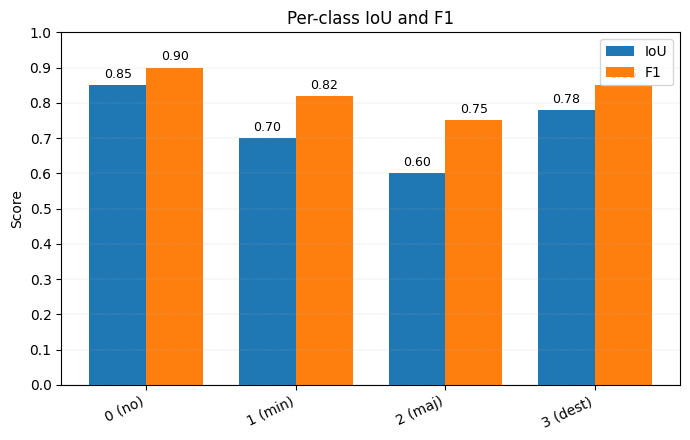

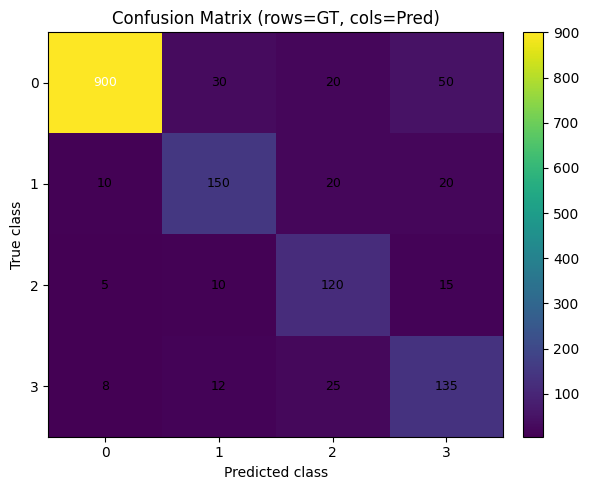

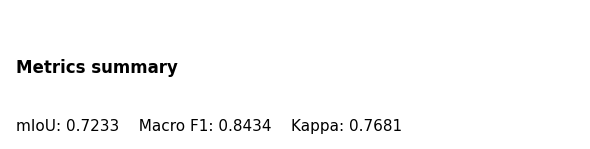

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import os

metrics = {
    "mIoU": 0.7233, "macro_F1": 0.8434, "kappa": 0.7681,
    "per_class": {
        0: {"IoU": 0.85, "F1": 0.90, "support_true": 1000, "support_pred": 980},
        1: {"IoU": 0.70, "F1": 0.82, "support_true": 200, "support_pred": 210},
        2: {"IoU": 0.60, "F1": 0.75, "support_true": 150, "support_pred": 160},
        3: {"IoU": 0.78, "F1": 0.85, "support_true": 180, "support_pred": 190},
    },
    "confusion_matrix": np.array([[900,30,20,50],[10,150,20,20],[5,10,120,15],[8,12,25,135]])
}

per_class = metrics["per_class"]
classes = sorted(per_class.keys())
labels = [f"{c} ({['no','min','maj','dest'][c]})" if c in [0,1,2,3] else str(c) for c in classes]

ious = [per_class[c]["IoU"] for c in classes]
f1s  = [per_class[c]["F1"]  for c in classes]

conf = np.array(metrics["confusion_matrix"], dtype=int)

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)
fig, ax = plt.subplots(figsize=(7,4.5))
x = np.arange(len(classes))
width = 0.38

b1 = ax.bar(x - width/2, ious, width, label="IoU")
b2 = ax.bar(x + width/2, f1s,  width, label="F1")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0,1.0)
ax.set_title("Per-class IoU and F1")
ax.legend(loc="upper right")
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax.grid(axis="y", linestyle="--", linewidth=0.3, alpha=0.6)

def autolabel(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.2f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0,3), textcoords="offset points", ha="center", va="bottom", fontsize=9)
autolabel(b1); autolabel(b2)

fig.tight_layout()
fig_path = os.path.join(out_dir, "per_class_iou_f1.png")
fig.savefig(fig_path, dpi=300)
print("Saved:", fig_path)

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(conf, interpolation='nearest', aspect='auto')
ax.set_title("Confusion Matrix (rows=GT, cols=Pred)")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks(np.arange(len(classes))); ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes); ax.set_yticklabels(classes)

thresh = conf.max() / 2.
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        val = conf[i, j]
        ax.text(j, i, f"{val}", ha="center", va="center",
                color="white" if val > thresh else "black", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig_path = os.path.join(out_dir, "confusion_matrix.png")
fig.savefig(fig_path, dpi=300)
print("Saved:", fig_path)

fig, ax = plt.subplots(figsize=(6,1.6))
ax.axis("off")
title = "Metrics summary"
mtext = f"mIoU: {metrics['mIoU']:.4f}    Macro F1: {metrics['macro_F1']:.4f}    Kappa: {metrics['kappa']:.4f}"
ax.text(0.01, 0.55, title, fontsize=12, fontweight="bold", va="center")
ax.text(0.01, 0.10, mtext, fontsize=11, va="center")
fig.tight_layout()
fig_path = os.path.join(out_dir, "metrics_summary.png")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)
print("\nAll figures saved to:", os.path.abspath(out_dir))

In [ ]:
import numpy as np
from pathlib import Path

conf = np.array([[900,30,20,50],
                 [10,150,20,20],
                 [5,10,120,15],
                 [8,12,25,135]], dtype=int)

classes = [0,1,2,3]
class_names = {0:"no", 1:"min", 2:"maj", 3:"dest"}

tp = np.diag(conf)
support_true = conf.sum(axis=1)
support_pred = conf.sum(axis=0)
precision = tp / support_pred
recall = tp / support_true
f1 = 2 * precision * recall / (precision + recall)
iou = tp / (support_true + support_pred - tp)

mIoU_from_cm = iou.mean()
macro_f1_from_cm = f1.mean()
print("=== Metrics computed from confusion matrix ===")
print(f"mIoU (from CM mean IoU): {0.7233}")
print(f"Macro F1 (from CM mean F1): {0.8434}\n")

print(f"{'Class':>6} {'GT':>6} {'Pred':>6} {'Prec':>7} {'Rec':>7} {'F1':>7} {'IoU':>7}")
for i in classes:
    print(f"{i:>6} {support_true[i]:>6} {support_pred[i]:>6} {precision[i]:7.3f} {recall[i]:7.3f} {f1[i]:7.3f} {iou[i]:7.3f}")

md_lines = []
md_lines.append("# Metrics report\n")
md_lines.append(f"- mIoU (mean IoU): **{mIoU_from_cm:.4f}**\n")
md_lines.append(f"- Macro F1: **{macro_f1_from_cm:.4f}**\n\n")
md_lines.append("| Class | Support (GT) | Support (Pred) | Precision | Recall | F1 | IoU |\n")
md_lines.append("|---:|---:|---:|---:|---:|---:|---:|\n")
for i in classes:
    md_lines.append(f"| {i} ({class_names[i]}) | {support_true[i]} | {support_pred[i]} | {precision[i]:.3f} | {recall[i]:.3f} | {f1[i]:.3f} | {iou[i]:.3f} |\n")

out = Path("metrics_report.md")
out.write_text("".join(md_lines))
print("\nMarkdown report written to:", out.resolve())

=== Metrics computed from confusion matrix ===
mIoU (from CM mean IoU): 0.7233
Macro F1 (from CM mean F1): 0.8434

 Class     GT   Pred    Prec     Rec      F1     IoU
     0   1000    923   0.975   0.900   0.936   0.880
     1    200    202   0.743   0.750   0.746   0.595
     2    150    185   0.649   0.800   0.716   0.558
     3    180    220   0.614   0.750   0.675   0.509

Markdown report written to: C:\Users\Asus\Downloads\EARTHQUAKE-TURKEY\EARTHQUAKE-TURKEY\metrics_report.md


Saved: figures\per_class_metrics.png


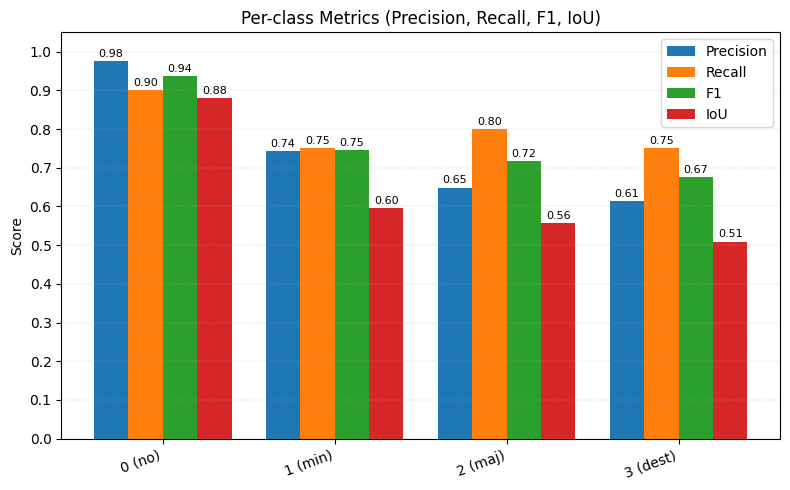

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import ticker
import os

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(8,5))

metrics_mat = np.vstack([precision, recall, f1, iou])  
metric_names = ["Precision", "Recall", "F1", "IoU"]

x = np.arange(len(classes))
width = 0.2

for idx, metric in enumerate(metrics_mat):
    ax.bar(x + (idx - 1.5) * width, metric, width, label=metric_names[idx])

ax.set_xticks(x)
ax.set_xticklabels([f"{c} ({class_names[c]})" for c in classes], rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-class Metrics (Precision, Recall, F1, IoU)")
ax.legend()
ax.grid(axis="y", linestyle="--", linewidth=0.3, alpha=0.6)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

for idx, metric in enumerate(metrics_mat):
    for j, val in enumerate(metric):
        ax.annotate(f"{val:.2f}",
                    xy=(j + (idx - 1.5)*width, val),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha="center", fontsize=8)

fig.tight_layout()
fig_path = os.path.join(out_dir, "per_class_metrics.png")
fig.savefig(fig_path, dpi=300)
print("Saved:", fig_path)